In [ ]:
# 


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import string
import re

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/BuhariS/spam_sms_collection/refs/heads/main/sms_spam_collection.csv")

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Check the distribution of the labels
class_counts = df["label"].value_counts()
class_counts

label
ham     4825
spam     747
Name: count, dtype: int64

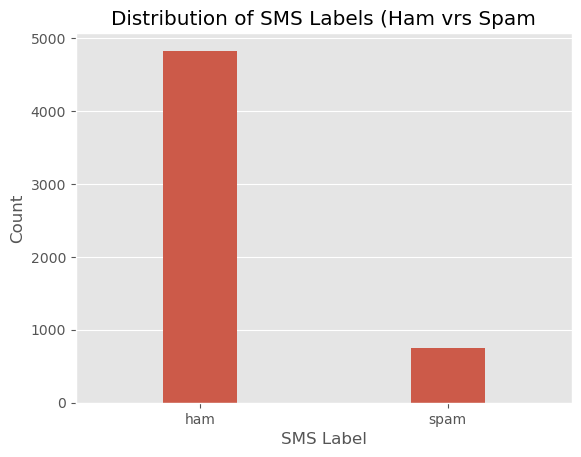

In [4]:
# Plot a bar chart of the class counts
fig, ax = plt.subplots()

sns.countplot(x = df["label"],
              width = 0.3,
              ax = ax)

ax.set(title = "Distribution of SMS Labels (Ham vrs Spam",
       xlabel = "SMS Label",
       ylabel = "Count")

plt.show()

In [5]:
# pd.set_option('future.no_silent_downcasting', True)
# Replace hamham with 0 and spam with 1
df["label"] = df["label"].map({"ham" : 0, "spam": 1})
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
# remove punctuations
def remove_punctuation(text):

    return "".join(char for char in text if char not in string.punctuation)

df["message"] = (df["message"]
                 .str.lower()
                 .apply(remove_punctuation)
                )

In [8]:
X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2, 
                                                    # stratify = y,
                                                    random_state = 42)

In [9]:
# Use the count vectorizer
stopwords_list = stopwords.words("English")

count_vectorizer = CountVectorizer(stop_words = stopwords_list,
                                  ngram_range = (1, 2),
                                  max_features = 2500
                                  )

X_train_count_vect = count_vectorizer.fit_transform(X_train)

X_test_count = count_vectorizer.transform(X_test)

In [10]:
model = LogisticRegression()

model.fit(X_train_count_vect, y_train)

y_preds = model.predict(X_test_count)

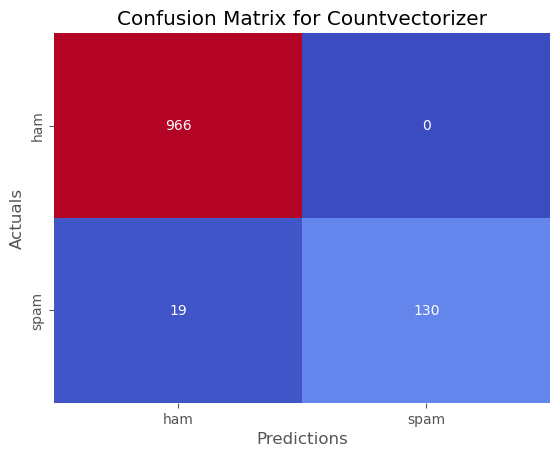

In [11]:
fig, ax = plt.subplots()

sns.heatmap(confusion_matrix(y_test, y_preds), 
            annot = True, 
            fmt=".0f", 
            cbar=False,
            xticklabels=["ham", "spam"],
            yticklabels=["ham", "spam"],
            cmap="coolwarm",
            ax = ax
            )

ax.set_title("Confusion Matrix for Countvectorizer")
ax.set_xlabel("Predictions")
ax.set_ylabel("Actuals")
plt.show()

In [12]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [13]:
# Instantiate the vectorizer
stopwords_list = stopwords.words("English")

vectorizer = TfidfVectorizer(
                lowercase = True,
                stop_words = stopwords_list,
                ngram_range = (1,2),
                max_features = 2500
               )

X_train_vect = vectorizer.fit_transform(X_train)

X_test_vect = vectorizer.transform(X_test)

In [14]:
# Train a logistic regression
lr = LogisticRegression()

lr.fit(X_train_vect, y_train)

y_preds = lr.predict(X_test_vect)

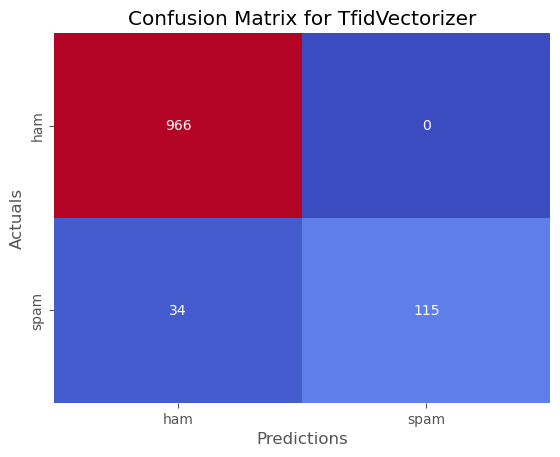

In [15]:
# plot a heatmap of the confusion matrix
fig, ax = plt.subplots()

sns.heatmap(confusion_matrix(y_test, y_preds), 
            annot = True, 
            fmt=".0f", 
            cbar=False,
            xticklabels=["ham", "spam"],
            yticklabels=["ham", "spam"],
            cmap="coolwarm",
            ax = ax)

ax.set_title("Confusion Matrix for TfidVectorizer")
ax.set_xlabel("Predictions")
ax.set_ylabel("Actuals")
plt.show()

In [16]:
# Check the performance of the model
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [17]:
# Test the model on fresh data
new_messages = [
    "Frank you have just won 3 million, click the link to claim it",
    "I love you so much"
]

new_vect = vectorizer.transform(new_messages)

predictions = lr.predict(new_vect)

for msg, pred in zip(new_messages, predictions):
    print(f"Message: {msg}")
    print("Prediction:", "Spam" if pred == 1 else "Ham")
    print()

Message: Frank you have just won 3 million, click the link to claim it
Prediction: Spam

Message: I love you so much
Prediction: Ham



In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 250, 
                            max_depth = 200,
                            random_state = 42
                           )

rf.fit(X_train_count_vect, y_train)

preds = rf.predict(X_test_count)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       1.00      0.83      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [19]:
confusion_matrix(y_test, preds)

array([[966,   0],
       [ 25, 124]], dtype=int64)